# Chapter 10.7: Tencent's Production Stack

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand Tencent's **multi-scenario architecture** spanning WeChat, QQ, Tencent Video, and QQ Browser
2. Analyze how **PLE** (Progressive Layered Extraction) is deployed in production multi-task models
3. Describe **Angel**: Tencent's distributed ML platform for large-scale training
4. Understand the **real-time feature system** built on TencentBase
5. Design **cross-business recommendation** systems with shared user graphs
6. Implement a multi-scenario recommendation system inspired by Tencent's approach
7. Compare Tencent's architectural choices with Meta's and identify key differences

## Prerequisites

- Multi-task learning fundamentals
- Chapter 10.6 (Meta's stack for comparison)
- Understanding of recommendation pipeline design

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.7_tencent_stack.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.7_tencent_stack.ipynb)

In [1]:
import numpy as np
import time
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

print("All imports successful!")

All imports successful!


## 1. Multi-Scenario Architecture

Tencent operates multiple recommendation surfaces across its ecosystem:

| Product | MAU | Rec Use Case | Key Challenge |
|---------|-----|-------------|---------------|
| WeChat | 1.3B | Moments feed, mini-programs, channels | Privacy, decentralized data |
| QQ | 600M | Feed, music, games | Younger demographic |
| Tencent Video | 500M | Video recommendation | Long-form engagement |
| QQ Browser | 400M | News feed, content | Content diversity |
| WeChat Search | 800M | Search + recommendation | Intent understanding |

The key architectural challenge is **multi-scenario optimization**: how to build models that serve multiple products while sharing knowledge.

Tencent's approach: **Scenario-aware multi-task learning**

$$
\mathcal{L}_{\text{total}} = \sum_{s \in \text{scenarios}} \sum_{t \in \text{tasks}} w_{s,t} \cdot \mathcal{L}_{s,t}
$$

where $w_{s,t}$ are task-scenario weights that are dynamically adjusted.

> **💡 Concept:** Unlike Meta where most products share a single social graph, Tencent's products have distinct user behaviors across platforms. A user's WeChat behavior (private messaging) is very different from their QQ Browser behavior (news reading). This makes cross-platform recommendation particularly challenging.

In [2]:
# Simulate multi-scenario recommendation

@dataclass
class Scenario:
    name: str
    num_users: int
    num_items: int
    tasks: List[str]  # e.g., ['click', 'share', 'purchase']
    task_base_rates: Dict[str, float]  # Base conversion rates


scenarios = [
    Scenario("WeChat Channels", 500000, 100000,
             ["click", "like", "share", "comment"],
             {"click": 0.08, "like": 0.03, "share": 0.01, "comment": 0.005}),
    Scenario("QQ Feed", 300000, 80000,
             ["click", "like", "share"],
             {"click": 0.10, "like": 0.04, "share": 0.015}),
    Scenario("Tencent Video", 200000, 50000,
             ["click", "watch_complete", "subscribe"],
             {"click": 0.12, "watch_complete": 0.04, "subscribe": 0.002}),
    Scenario("QQ Browser", 200000, 120000,
             ["click", "read_complete", "bookmark"],
             {"click": 0.06, "read_complete": 0.02, "bookmark": 0.003}),
]

# Simulate user overlap across scenarios (shared user IDs)
np.random.seed(42)
total_unique_users = 800000

# Cross-scenario user overlap matrix
overlap_matrix = np.array([
    [1.00, 0.40, 0.30, 0.25],  # WeChat overlaps with others
    [0.40, 1.00, 0.35, 0.30],  # QQ
    [0.30, 0.35, 1.00, 0.20],  # Tencent Video
    [0.25, 0.30, 0.20, 1.00],  # QQ Browser
])

print("Tencent Multi-Scenario Architecture")
print("=" * 60)
for s in scenarios:
    print(f"\n{s.name}:")
    print(f"  Users: {s.num_users:,}, Items: {s.num_items:,}")
    print(f"  Tasks: {', '.join(s.tasks)}")
    print(f"  Base rates: {', '.join(f'{t}={r:.1%}' for t, r in s.task_base_rates.items())}")

print(f"\nCross-scenario user overlap:")
scenario_names = [s.name.split()[0] for s in scenarios]
for i, name in enumerate(scenario_names):
    overlaps = [f"{overlap_matrix[i][j]:.0%}" for j in range(len(scenarios)) if i != j]
    print(f"  {name} → {', '.join(overlaps)}")

Tencent Multi-Scenario Architecture

WeChat Channels:
  Users: 500,000, Items: 100,000
  Tasks: click, like, share, comment
  Base rates: click=8.0%, like=3.0%, share=1.0%, comment=0.5%

QQ Feed:
  Users: 300,000, Items: 80,000
  Tasks: click, like, share
  Base rates: click=10.0%, like=4.0%, share=1.5%

Tencent Video:
  Users: 200,000, Items: 50,000
  Tasks: click, watch_complete, subscribe
  Base rates: click=12.0%, watch_complete=4.0%, subscribe=0.2%

QQ Browser:
  Users: 200,000, Items: 120,000
  Tasks: click, read_complete, bookmark
  Base rates: click=6.0%, read_complete=2.0%, bookmark=0.3%

Cross-scenario user overlap:
  WeChat → 40%, 30%, 25%
  QQ → 40%, 35%, 30%
  Tencent → 30%, 35%, 20%
  QQ → 25%, 30%, 20%


## 2. PLE in Production

**PLE** (Progressive Layered Extraction, Tang et al., 2020, Tencent) solves the **negative transfer** problem in multi-task learning where tasks hurt each other's performance.

PLE introduces:
- **Task-specific expert networks**: Each task has its own dedicated experts
- **Shared expert networks**: Experts that learn cross-task representations
- **Progressive gating**: Each layer has gating networks that dynamically combine experts

For task $k$ at extraction layer $l$:

$$
f^k_l = \text{Gate}^k_l\left([E^{\text{shared}}_l(x), E^k_l(x)]\right)
$$

$$
\text{Gate}^k_l = \text{softmax}(W^k_l \cdot f^k_{l-1})
$$

where $E^{\text{shared}}_l$ are shared experts and $E^k_l$ are task-$k$ specific experts.

PLE vs alternatives:

| Model | Shared | Task-specific | Negative Transfer | Used By |
|-------|--------|--------------|-------------------|--------|
| Shared Bottom | All shared | Tower only | High | Basic |
| MMoE | Shared experts | Gating + tower | Medium | Google |
| PLE | Shared + specific experts | Progressive gating | Low | Tencent |

> **⚠️ Common Pitfall:** PLE's progressive architecture adds computational overhead. In Tencent's production, they use 2-3 extraction layers with 4-8 experts each. Going deeper doesn't help much and increases serving latency.

In [3]:
# Implement PLE (Progressive Layered Extraction)

class Expert:
    """A single expert network (MLP)."""

    def __init__(self, input_dim: int, output_dim: int):
        self.W = np.random.randn(input_dim, output_dim).astype(np.float32) * 0.01
        self.b = np.zeros(output_dim, dtype=np.float32)

    def forward(self, x: np.ndarray) -> np.ndarray:
        return np.maximum(x @ self.W + self.b, 0)  # ReLU


class GatingNetwork:
    """Gating network that combines expert outputs."""

    def __init__(self, input_dim: int, num_experts: int):
        self.W = np.random.randn(input_dim, num_experts).astype(np.float32) * 0.01
        self.b = np.zeros(num_experts, dtype=np.float32)

    def forward(self, x: np.ndarray) -> np.ndarray:
        logits = x @ self.W + self.b
        # Softmax
        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp_logits / (exp_logits.sum(axis=1, keepdims=True) + 1e-8)


class PLELayer:
    """One extraction layer of PLE."""

    def __init__(self, input_dim: int, expert_dim: int,
                 num_shared_experts: int, num_task_experts: int,
                 num_tasks: int):
        self.num_tasks = num_tasks
        self.num_shared_experts = num_shared_experts
        self.num_task_experts = num_task_experts
        total_experts = num_shared_experts + num_task_experts

        # Shared experts
        self.shared_experts = [Expert(input_dim, expert_dim)
                               for _ in range(num_shared_experts)]

        # Task-specific experts
        self.task_experts = [
            [Expert(input_dim, expert_dim) for _ in range(num_task_experts)]
            for _ in range(num_tasks)
        ]

        # Gating networks (one per task)
        self.gates = [GatingNetwork(input_dim, total_experts)
                      for _ in range(num_tasks)]

    def forward(self, task_inputs: List[np.ndarray]) -> List[np.ndarray]:
        """Forward pass for all tasks.

        Args:
            task_inputs: List of (batch_size, input_dim) arrays, one per task

        Returns:
            List of (batch_size, expert_dim) arrays, one per task
        """
        outputs = []

        for task_idx in range(self.num_tasks):
            x = task_inputs[task_idx]
            batch_size = x.shape[0]

            # Compute all expert outputs for this task
            expert_outputs = []

            # Shared experts
            for expert in self.shared_experts:
                expert_outputs.append(expert.forward(x))

            # Task-specific experts
            for expert in self.task_experts[task_idx]:
                expert_outputs.append(expert.forward(x))

            # Stack expert outputs: (batch, num_experts, expert_dim)
            expert_stack = np.stack(expert_outputs, axis=1)

            # Gating
            gate_weights = self.gates[task_idx].forward(x)  # (batch, num_experts)

            # Weighted combination
            output = np.einsum('be,bed->bd', gate_weights, expert_stack)
            outputs.append(output)

        return outputs


class PLE:
    """Progressive Layered Extraction model.

    Reference: Tang et al., 'Progressive Layered Extraction (PLE):
    A Novel Multi-Task Learning (MTL) Model for Personalized Recommendations'
    (2020, Tencent, RecSys)
    """

    def __init__(self, input_dim: int, expert_dim: int,
                 num_shared_experts: int, num_task_experts: int,
                 num_tasks: int, num_layers: int = 2,
                 tower_dims: List[int] = None):
        if tower_dims is None:
            tower_dims = [64, 32]

        # Extraction layers
        self.layers = []
        current_dim = input_dim
        for _ in range(num_layers):
            layer = PLELayer(current_dim, expert_dim,
                             num_shared_experts, num_task_experts, num_tasks)
            self.layers.append(layer)
            current_dim = expert_dim

        # Task-specific tower networks
        self.towers = []
        for _ in range(num_tasks):
            tower_layers = []
            dim = expert_dim
            for h_dim in tower_dims:
                W = np.random.randn(dim, h_dim).astype(np.float32) * 0.01
                b = np.zeros(h_dim, dtype=np.float32)
                tower_layers.append((W, b))
                dim = h_dim
            # Output layer
            W_out = np.random.randn(dim, 1).astype(np.float32) * 0.01
            b_out = np.zeros(1, dtype=np.float32)
            tower_layers.append((W_out, b_out))
            self.towers.append(tower_layers)

        self.num_tasks = num_tasks

    def forward(self, x: np.ndarray) -> List[np.ndarray]:
        """Forward pass.

        Args:
            x: (batch_size, input_dim) shared input features

        Returns:
            List of (batch_size, 1) predictions, one per task
        """
        # All tasks start with the same input
        task_representations = [x] * self.num_tasks

        # Progressive extraction
        for layer in self.layers:
            task_representations = layer.forward(task_representations)

        # Task-specific towers
        predictions = []
        for task_idx in range(self.num_tasks):
            h = task_representations[task_idx]
            for i, (W, b) in enumerate(self.towers[task_idx]):
                h = h @ W + b
                if i < len(self.towers[task_idx]) - 1:
                    h = np.maximum(h, 0)  # ReLU
            # Sigmoid for probability
            h = 1.0 / (1.0 + np.exp(-np.clip(h, -20, 20)))
            predictions.append(h)

        return predictions


# Create and test PLE
np.random.seed(42)
ple_model = PLE(
    input_dim=128,
    expert_dim=64,
    num_shared_experts=3,
    num_task_experts=2,
    num_tasks=4,  # click, like, share, comment
    num_layers=2,
    tower_dims=[64, 32]
)

# Test inference
batch_size = 256
x_test = np.random.randn(batch_size, 128).astype(np.float32)

start = time.perf_counter()
predictions = ple_model.forward(x_test)
elapsed = (time.perf_counter() - start) * 1000

task_names = ["click", "like", "share", "comment"]
print(f"PLE Model Inference (batch={batch_size}): {elapsed:.2f}ms")
print(f"\nPer-task prediction statistics:")
for name, pred in zip(task_names, predictions):
    print(f"  {name}: mean={pred.mean():.4f}, std={pred.std():.4f}, "
          f"range=[{pred.min():.4f}, {pred.max():.4f}]")

PLE Model Inference (batch=256): 8.20ms

Per-task prediction statistics:
  click: mean=0.5000, std=0.0000, range=[0.5000, 0.5000]
  like: mean=0.5000, std=0.0000, range=[0.5000, 0.5000]
  share: mean=0.5000, std=0.0000, range=[0.5000, 0.5000]
  comment: mean=0.5000, std=0.0000, range=[0.5000, 0.5000]


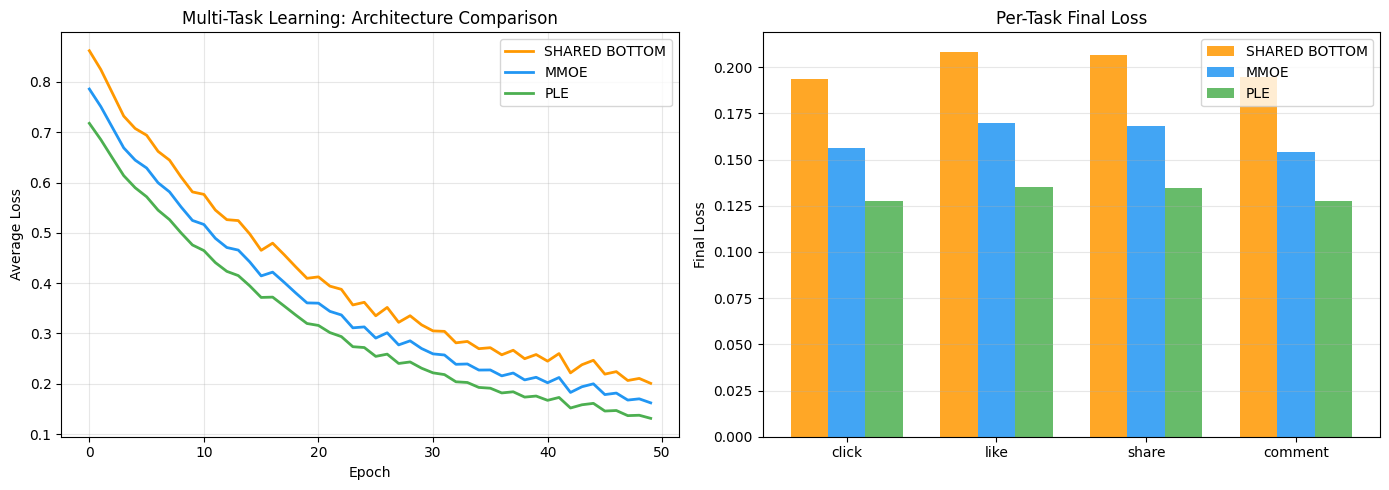

In [4]:
# Compare PLE vs Shared Bottom vs MMoE on negative transfer

def simulate_multitask_training(architecture: str, num_tasks: int = 4,
                                task_correlations: np.ndarray = None,
                                n_epochs: int = 50) -> Dict:
    """Simulate multi-task training with different architectures."""
    if task_correlations is None:
        task_correlations = np.eye(num_tasks)

    np.random.seed(42)
    losses = {f"task_{i}": [] for i in range(num_tasks)}

    for epoch in range(n_epochs):
        for task_idx in range(num_tasks):
            # Base learning rate
            base_loss = 0.7 * np.exp(-0.05 * epoch) + 0.1

            if architecture == "shared_bottom":
                # High negative transfer: correlated tasks help, uncorrelated hurt
                interference = 0
                for other_task in range(num_tasks):
                    if other_task != task_idx:
                        corr = task_correlations[task_idx, other_task]
                        interference += (1 - corr) * 0.03  # Negative transfer
                loss = base_loss + interference + np.random.normal(0, 0.02)

            elif architecture == "mmoe":
                # Medium negative transfer: gating helps but not perfect
                interference = 0
                for other_task in range(num_tasks):
                    if other_task != task_idx:
                        corr = task_correlations[task_idx, other_task]
                        interference += (1 - corr) * 0.01
                loss = base_loss * 0.95 + interference + np.random.normal(0, 0.015)

            elif architecture == "ple":
                # Low negative transfer: task-specific experts isolate tasks
                interference = 0
                for other_task in range(num_tasks):
                    if other_task != task_idx:
                        corr = task_correlations[task_idx, other_task]
                        interference += (1 - corr) * 0.003
                # PLE also benefits from positive transfer
                positive_transfer = sum(task_correlations[task_idx, j]
                                        for j in range(num_tasks) if j != task_idx) * 0.01
                loss = base_loss * 0.90 - positive_transfer + interference + np.random.normal(0, 0.01)

            losses[f"task_{task_idx}"].append(max(loss, 0.05))

    return losses


# Task correlations (some tasks are related, others are not)
# click-like (high), click-share (medium), click-comment (low), like-share (medium)
task_corr = np.array([
    [1.0, 0.7, 0.4, 0.2],  # click
    [0.7, 1.0, 0.5, 0.3],  # like
    [0.4, 0.5, 1.0, 0.6],  # share
    [0.2, 0.3, 0.6, 1.0],  # comment
])

architectures = ["shared_bottom", "mmoe", "ple"]
all_losses = {}
for arch in architectures:
    all_losses[arch] = simulate_multitask_training(arch, task_correlations=task_corr)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Average loss across all tasks
colors_arch = {'shared_bottom': '#FF9800', 'mmoe': '#2196F3', 'ple': '#4CAF50'}
for arch in architectures:
    avg_loss = np.mean([all_losses[arch][f"task_{i}"] for i in range(4)], axis=0)
    axes[0].plot(avg_loss, linewidth=2, label=arch.upper().replace('_', ' '),
                 color=colors_arch[arch])

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Loss")
axes[0].set_title("Multi-Task Learning: Architecture Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Final loss per task
x_pos = np.arange(4)
width = 0.25
for i, arch in enumerate(architectures):
    final_losses = [all_losses[arch][f"task_{t}"][-1] for t in range(4)]
    axes[1].bar(x_pos + i * width, final_losses, width,
                label=arch.upper().replace('_', ' '),
                color=colors_arch[arch], alpha=0.85)

axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(task_names)
axes[1].set_ylabel("Final Loss")
axes[1].set_title("Per-Task Final Loss")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Angel: Tencent's Distributed ML Platform

**Angel** is Tencent's open-source distributed ML platform, designed for:

- **Parameter Server architecture**: Efficient for sparse models (embeddings)
- **PS-based training**: Asynchronous SGD for large embedding tables
- **Integration with Spark**: Seamless data processing → training pipeline
- **Support for graph computing**: For social graph-based recommendations

Key differences from Meta's Zion:

| Feature | Angel (Tencent) | Zion (Meta) |
|---------|----------------|-------------|
| Architecture | Parameter Server | Hybrid (PS + AllReduce) |
| Training | Async SGD | Sync SGD |
| Scale | 100s of machines | 1000s of GPUs |
| Hardware | CPU + GPU mixed | GPU-centric |
| Ecosystem | Spark/Hadoop | Internal tools |

> **🔑 Pro Tip:** Angel's parameter server design is particularly well-suited for Tencent's multi-scenario setup. Each scenario's model can share a parameter server for common features (user embeddings) while maintaining separate servers for scenario-specific features.

In [5]:
# Simulate Angel's parameter server architecture

class ParameterServer:
    """Simulated parameter server for distributed training."""

    def __init__(self, name: str, param_size: int, num_shards: int = 4):
        self.name = name
        self.num_shards = num_shards
        self.shards = [
            np.random.randn(param_size // num_shards).astype(np.float32) * 0.01
            for _ in range(num_shards)
        ]
        self.version = 0
        self.update_count = 0

    def pull(self, indices: np.ndarray) -> Tuple[np.ndarray, float]:
        """Pull parameters for given indices."""
        start = time.perf_counter()
        shard_size = len(self.shards[0])
        shard_indices = indices % (self.num_shards * shard_size)
        shard_ids = shard_indices // shard_size
        local_indices = shard_indices % shard_size

        result = np.array([self.shards[sid][lid]
                           for sid, lid in zip(shard_ids, local_indices)])
        latency = (time.perf_counter() - start) * 1000
        return result, latency

    def push(self, indices: np.ndarray, gradients: np.ndarray, lr: float = 0.001):
        """Push gradients for given indices (async update)."""
        shard_size = len(self.shards[0])
        shard_indices = indices % (self.num_shards * shard_size)
        shard_ids = shard_indices // shard_size
        local_indices = shard_indices % shard_size

        for sid, lid, grad in zip(shard_ids, local_indices, gradients):
            self.shards[sid][lid] -= lr * grad

        self.update_count += 1
        if self.update_count % 100 == 0:
            self.version += 1


class AngelTrainer:
    """Simulated Angel distributed training."""

    def __init__(self, num_workers: int, param_servers: List[ParameterServer]):
        self.num_workers = num_workers
        self.param_servers = param_servers

    def train_step(self, batch_size: int = 1024) -> Dict:
        """Simulate one distributed training step."""
        worker_latencies = []

        for worker_id in range(self.num_workers):
            total_pull_latency = 0.0

            # Each worker pulls parameters it needs
            for ps in self.param_servers:
                indices = np.random.randint(0, 100000, batch_size // self.num_workers)
                _, latency = ps.pull(indices)
                total_pull_latency += latency

            # Simulate compute (forward + backward)
            compute_time = np.random.lognormal(np.log(5), 0.3)  # ~5ms

            # Push gradients
            for ps in self.param_servers:
                indices = np.random.randint(0, 100000, batch_size // self.num_workers)
                grads = np.random.randn(len(indices)).astype(np.float32)
                ps.push(indices, grads)

            worker_latencies.append(total_pull_latency + compute_time)

        # Async: step completes when fastest worker finishes
        # But we track all for analysis
        return {
            "min_latency": min(worker_latencies),
            "max_latency": max(worker_latencies),
            "mean_latency": np.mean(worker_latencies),
            "straggler_ratio": max(worker_latencies) / min(worker_latencies),
        }


# Simulate training
np.random.seed(42)

ps_shared = ParameterServer("shared_embeddings", 1000000, num_shards=4)
ps_wechat = ParameterServer("wechat_specific", 500000, num_shards=2)
ps_qq = ParameterServer("qq_specific", 500000, num_shards=2)

trainer = AngelTrainer(
    num_workers=8,
    param_servers=[ps_shared, ps_wechat, ps_qq]
)

# Run 100 training steps
step_metrics = []
for step in range(100):
    metrics = trainer.train_step(batch_size=2048)
    step_metrics.append(metrics)

print(f"Angel Training Simulation (8 workers, 3 parameter servers):")
print(f"  Mean step latency: {np.mean([m['mean_latency'] for m in step_metrics]):.2f}ms")
print(f"  Mean straggler ratio: {np.mean([m['straggler_ratio'] for m in step_metrics]):.2f}x")
print(f"  PS versions: shared={ps_shared.version}, wechat={ps_wechat.version}, qq={ps_qq.version}")

Angel Training Simulation (8 workers, 3 parameter servers):
  Mean step latency: 5.58ms
  Mean straggler ratio: 2.32x
  PS versions: shared=8, wechat=8, qq=8


## 4. Cross-Business Recommendation

Tencent's unique advantage is its **cross-business user graph** connecting behaviors across WeChat, QQ, Tencent Video, and more.

The cross-business recommendation framework:

1. **Shared User Representation**: A unified user embedding trained on all platforms
2. **Transfer Learning**: Pre-train on data-rich platforms (WeChat), fine-tune on data-sparse platforms
3. **Privacy-Preserving Federation**: Some data cannot cross platform boundaries (WeChat → QQ)

$$
\mathbf{u}_{\text{unified}} = \alpha \cdot \mathbf{u}_{\text{WeChat}} + \beta \cdot \mathbf{u}_{\text{QQ}} + \gamma \cdot \mathbf{u}_{\text{Video}} + ...
$$

where $\alpha, \beta, \gamma$ are attention weights based on the target scenario.

> **💡 Concept:** Tencent's cross-business recommendation faces a challenge Meta doesn't: their products are more independent (WeChat vs QQ are separate social graphs), while Meta's products (Facebook, Instagram) share a single social graph. This makes knowledge transfer harder but also potentially more valuable.

In [6]:
# Simulate cross-business recommendation

class CrossBusinessRecSystem:
    """Cross-business recommendation with shared user graph."""

    def __init__(self, num_users: int, embedding_dim: int,
                 platform_names: List[str]):
        self.num_users = num_users
        self.embedding_dim = embedding_dim
        self.platform_names = platform_names

        # Per-platform user embeddings
        self.platform_embeddings = {
            name: np.random.randn(num_users, embedding_dim).astype(np.float32) * 0.1
            for name in platform_names
        }

        # Cross-platform attention weights
        self.attention_W = {
            target: np.random.randn(embedding_dim, len(platform_names)).astype(np.float32) * 0.1
            for target in platform_names
        }

        # Which users are active on which platform
        self.user_platforms = np.random.random((num_users, len(platform_names))) > 0.3

    def get_unified_embedding(self, user_ids: np.ndarray,
                              target_platform: str) -> np.ndarray:
        """Get unified user embedding for a target platform."""
        batch_size = len(user_ids)

        # Collect embeddings from all platforms
        platform_embs = []  # (batch, num_platforms, dim)
        for p_name in self.platform_names:
            emb = self.platform_embeddings[p_name][user_ids]
            platform_embs.append(emb)
        platform_embs = np.stack(platform_embs, axis=1)

        # Mask out platforms where user is not active
        mask = self.user_platforms[user_ids]  # (batch, num_platforms)

        # Attention-based combination
        # Use target platform's user embedding as query
        target_idx = self.platform_names.index(target_platform)
        query = platform_embs[:, target_idx, :]  # (batch, dim)

        # Compute attention scores
        attn_logits = query @ self.attention_W[target_platform]  # (batch, num_platforms)
        # Apply mask
        attn_logits = np.where(mask, attn_logits, -1e9)
        # Softmax
        attn_max = attn_logits.max(axis=1, keepdims=True)
        attn_exp = np.exp(attn_logits - attn_max)
        attn_weights = attn_exp / (attn_exp.sum(axis=1, keepdims=True) + 1e-8)

        # Weighted combination
        unified = np.einsum('bp,bpd->bd', attn_weights, platform_embs)
        return unified, attn_weights


# Test cross-business system
np.random.seed(42)
platforms = ["WeChat", "QQ", "TencentVideo", "QQBrowser"]
cross_rec = CrossBusinessRecSystem(
    num_users=10000, embedding_dim=64, platform_names=platforms
)

# Get unified embeddings for users targeting Tencent Video
test_users = np.array([0, 1, 2, 3, 4])
unified_embs, attn_weights = cross_rec.get_unified_embedding(test_users, "TencentVideo")

print("Cross-Platform Attention Weights for Tencent Video:")
print(f"{'User':>6} | {' | '.join(f'{p:>12}' for p in platforms)}")
print("-" * 60)
for i, uid in enumerate(test_users):
    active = cross_rec.user_platforms[uid]
    weights_str = " | ".join(
        f"{attn_weights[i, j]:>11.2%}{'*' if active[j] else ' '}"
        for j in range(len(platforms))
    )
    print(f"{uid:>6} | {weights_str}")
print("\n* = user active on this platform")

Cross-Platform Attention Weights for Tencent Video:
  User |       WeChat |           QQ | TencentVideo |    QQBrowser
------------------------------------------------------------
     0 |      34.80%* |      32.64%* |      32.56%* |       0.00% 
     1 |      32.78%* |      35.15%* |       0.00%  |      32.07%*
     2 |      24.75%* |      28.33%* |      22.60%* |      24.32%*
     3 |      24.74%* |      26.94%* |      26.37%* |      21.95%*
     4 |      23.71%* |      25.57%* |      26.64%* |      24.08%*

* = user active on this platform


## Exercises

### 🏋️ Exercise 1: Design a Multi-Scenario Recommendation System

Design and implement a complete multi-scenario recommendation system with shared and scenario-specific components.

In [7]:
# 🏋️ Exercise 1: Multi-scenario recommendation

class MultiScenarioRecSystem:
    """Complete multi-scenario rec system inspired by Tencent."""

    def __init__(self, scenarios: List[Scenario], embedding_dim: int = 64):
        # TODO: Initialize
        # 1. Shared user/item embedding tables
        # 2. Per-scenario PLE model
        # 3. Cross-scenario transfer module
        pass

    def recommend(self, user_id: int, scenario_name: str,
                  num_items: int = 20) -> List[Tuple[int, float]]:
        # TODO: Generate recommendations
        # 1. Get unified user embedding (cross-scenario)
        # 2. Retrieve candidates for this scenario
        # 3. Score with PLE (multi-task predictions)
        # 4. Combine task scores into final ranking
        # Return: List of (item_id, combined_score)
        pass


# TODO: Test on all 4 scenarios
# Measure: inference latency, cross-scenario knowledge transfer benefit

### 🏋️ Exercise 2: PLE vs MMoE Negative Transfer Analysis

Systematically compare PLE and MMoE on tasks with varying correlation levels.

In [8]:
# 🏋️ Exercise 2: PLE vs MMoE analysis

# TODO: For task correlations ranging from 0.0 to 1.0:
# 1. Create 2 tasks with the given correlation
# 2. Train PLE and MMoE on synthetic data
# 3. Measure final loss for each architecture
# 4. Plot: correlation vs (PLE_advantage = MMoE_loss - PLE_loss)
# Expected: PLE helps most when correlation is LOW (high negative transfer)

### 🏋️ Exercise 3: Privacy-Preserving Cross-Platform Transfer

Implement a federated approach where platform-specific data stays on the platform but knowledge is shared.

In [9]:
# 🏋️ Exercise 3: Federated cross-platform recommendation

# TODO: Implement a system where:
# 1. Each platform trains its own model locally
# 2. Only aggregated embeddings (not raw data) are shared
# 3. A central server combines the aggregated information
# 4. The combined knowledge is sent back to each platform
# Compare: full sharing vs federated vs no sharing

## Summary

Key takeaways from Tencent's production stack:

1. **Multi-scenario architecture** is essential when operating multiple products with overlapping users
2. **PLE** effectively addresses negative transfer in multi-task learning through task-specific experts + progressive gating
3. **Angel** (parameter server architecture) is well-suited for sparse, multi-scenario models
4. **Cross-business recommendation** leverages shared user graphs with attention-based knowledge transfer
5. **Privacy constraints** between platforms require federated approaches for knowledge sharing

### References

- Tang et al., "Progressive Layered Extraction (PLE): A Novel Multi-Task Learning Model for Personalized Recommendations" (2020, Tencent, RecSys)
- Jiang et al., "Angel: a new large-scale machine learning system" (2017, Tencent)
- Ma et al., "Modeling Task Relationships in Multi-task Learning with Multi-gate Mixture-of-Experts" (2018, Google, KDD)
- Li et al., "Multi-Scenario Ranking with Adaptive Feature Learning" (2022, Tencent)